# $\alpha$-Particle Dynamics in Stellarators: Reference Trajectory Analysis and Validation

## Overview

This notebook provides analysis and validation of the reference trajectories generated by numerical simulations of the $\alpha$-particle problem. 

In particular, this notebook will:
1. Load and visualize reference trajectories for different parameters and initial conditions
2. Compute Taylor series approximations and compare against high-accuracy reference solutions
3. Load and visualize reference Poincaré sections 

## Mathematical Model

Let $B:\mathbb{R}^2\rightarrow\mathbb{R}$ be a smooth positive function bounded away from zero, and let $\epsilon\in\mathbb{R}$ be a non-negative constant. The system of ODEs 
\begin{equation*}
    \begin{split}
        \dot{v}_x &= B(x,y)\,v_y,\\
        \dot{v}_y & = -B(x,y)\,v_x,\\
        \dot{x} & = \epsilon\,v_x,\\
        \dot{y} & = \epsilon\,v_y,
    \end{split}
\end{equation*}
describes the motion of a charged particle in the magnetic field $\bm{B}:\mathbb{R}^3\rightarrow\mathbb{R}^3$ given by $\bm{B}(x,y,z) = B(x,y)\,\bm{e}_z$, where $\bm{e}_z$ is the unit vector in the $z$-direction. In this formulation, the system phase space is $4$-dimensional with coordinates $(v_x,v_y,x,y)$, which can be understood as a symmetry reduction from the full $6$-dimensional phase space $(\bm{v},\bm{x})\in\mathbb{R}^3\times\mathbb{R}^3$. The reduction stems from the translational symmetry in the $z$-direction,  $(\bm{v},\bm{x})\mapsto (\bm{v},\bm{x} + \lambda\,\bm{e}_z)$, which conserves the component $v_z$. 

The magnetic field is modeled as:
\begin{align*}
B(x,y) = B_0 + a_1\,\cos(k_{x1}\,x + k_{y1}\,y) + a_2\,\cos(k_{x2}\,x + k_{y2}\,y),
\end{align*}
where $B_0 = 1$, $ a_1 =a_2 = 0.3$ , $ k_{x_1} = 3$, $k_{y_1} = 1$, $k_{x_2} = 1$, $ k_{y_2} = 3$.


## Setup and Dependencies

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from notebook_utils.dataprocessing import AlphaParticle, AlphaParticleTrajectory, AlphaParticleDataset
from notebook_utils.visualization import AlphaParticleVisualizer

Trajectory = AlphaParticleTrajectory
Dataset = AlphaParticleDataset

viz = AlphaParticleVisualizer()

## Analysis 
### 1. Same $\epsilon$ Parameter, Different Initial Conditions

We load three reference trajectories with the same $\epsilon$ but different initial conditions:
- Trajectory 1: $(v_x, v_y, x, y) = (\sqrt{2}, 0, 2.5, 3.0)$
- Trajectory 2: $(v_x, v_y, x, y) = (1, 1, 2.5, 3.0)$  
- Trajectory 3: $(v_x, v_y, x, y) = (1, -1, 2.5, 3.0)$

We visualize these trajectories in the xy-plane superimposed on contours of the magnetic field (coolwarm colormap). 

We can also compare the time series plots of various quantities. 


Initial conditions for each trajectory:
Trajectory 1: [1.41421356 0.         2.5        3.        ]
Trajectory 2: [1.  1.  2.5 3. ]
Trajectory 3: [ 1.  -1.   2.5  3. ]


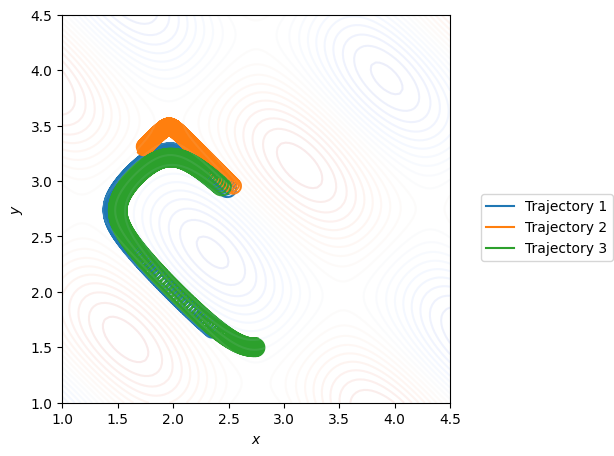

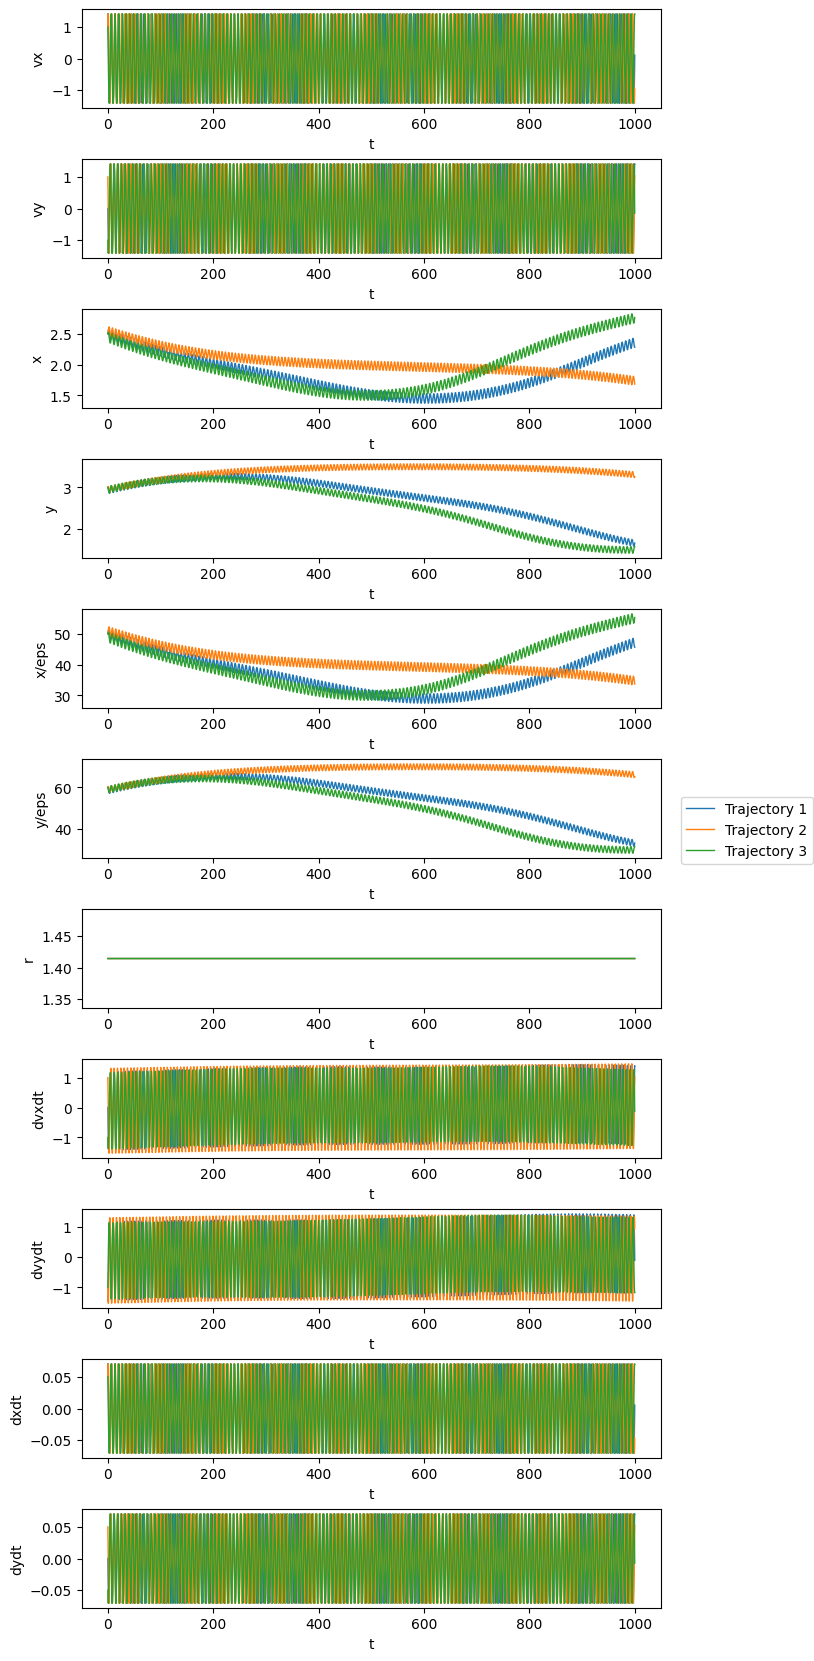

In [2]:
# Set parameter
epsilon = 0.05

# Define trajectory indices and labels
traj_indices = [1, 2, 3]
traj_labels = ["Trajectory {}".format(i) for i in traj_indices]

# Get reference trajectory filepaths
ref_filepaths = AlphaParticle.get_reference_filepaths("default")

# Load reference trajectories
ref_trajs = [
    Trajectory.load_from_file(
        ref_filepaths[epsilon][i]["filepath"], 
        dt=ref_filepaths[epsilon][i]["dt"],
        epsilon=epsilon,) 
    for i in traj_indices
]

# Create processor for computing derivatives and magnetic field
processor = AlphaParticle(epsilon=epsilon)

# Display initial conditions for verification
print("Initial conditions for each trajectory:")
for i, traj in enumerate(ref_trajs):
    print(f"Trajectory {i+1}: {traj.states.u[0]}")

# Select time window for analysis (t = 0 to 1000)
trajs = [traj.select_between(0, 1000) for traj in ref_trajs]

# Plot trajectories in the xy-plane
viz.plot_xy(
    trajs, 
    axis_lims=[(1, 4.5), (1, 4.5)],
    figsize=(6, 5), 
    legend_labels=traj_labels,
    show_legend=True
)

# Plot the time series of various quantities
viz.plot_history(
    trajs,
    func_dict={
        'vx': lambda u: u[:, 0], 
        'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 
        'y': lambda u: u[:, 3], 
        'x/eps': lambda u: u[:, 2]/epsilon, 
        'y/eps': lambda u: u[:, 3]/epsilon, 
        'r': lambda u: np.sqrt(u[:, 0]**2 + u[:, 1]**2),
        'dvxdt': lambda u: processor.compute_du(u)[:, 0],
        'dvydt': lambda u: processor.compute_du(u)[:, 1],
        'dxdt': lambda u: processor.compute_du(u)[:, 2],
        'dydt': lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t', 
    legend_labels=traj_labels,
    show_legend=True
)

In [3]:
viz.plot_history_matlab(
    trajs,
    func_dict={
        'vx': lambda u: u[:, 0], 
        'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 
        'y': lambda u: u[:, 3], 
        'x/eps': lambda u: u[:, 2]/epsilon, 
        'y/eps': lambda u: u[:, 3]/epsilon, 
        'r': lambda u: np.sqrt(u[:, 0]**2 + u[:, 1]**2),
        'dvxdt': lambda u: processor.compute_du(u)[:, 0],
        'dvydt': lambda u: processor.compute_du(u)[:, 1],
        'dxdt': lambda u: processor.compute_du(u)[:, 2],
        'dydt': lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t', 
    legend_labels=traj_labels,
    show_legend=True,
    save_path=f"./out/alphaparticle/eps=5e-2/traj_history_matlab.pdf"
)

legend_handles: [<matlab.object object at 0x30bf3c970>, <matlab.object object at 0x30bf3ca90>, <matlab.object object at 0x30bf3f330>]
3
Current figure size: 8.0" x 22.0"
New figure size: 3.0" x 8.2"
Saved figure as: ./out/alphaparticle/eps=5e-2/traj_history_matlab.pdf and ./out/alphaparticle/eps=5e-2/traj_history_matlab.fig


### 2. Same Initial Condition, Different $\epsilon$ Parameter

To investigate the $\epsilon$ sensitivity, we use an identical initial condition $(v_x, v_y, x, y) = (1, -1, 2.5, 3.0)$ and vary $\epsilon$ across the range [0.05, 0.15, 0.27, 0.3, 0.4]. We then compare xy-plane trajectories and time series plots. 

Initial state: [ 1.  -1.   2.5  3. ]
Initial state: [ 1.  -1.   2.5  3. ]
Initial state: [ 1.  -1.   2.5  3. ]
Initial state: [ 1.  -1.   2.5  3. ]
Initial state: [ 1.  -1.   2.5  3. ]


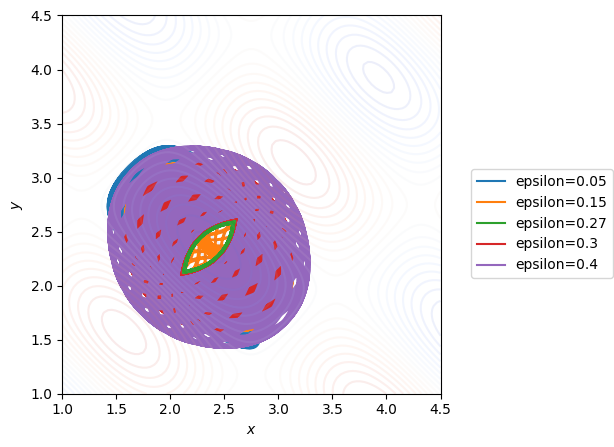

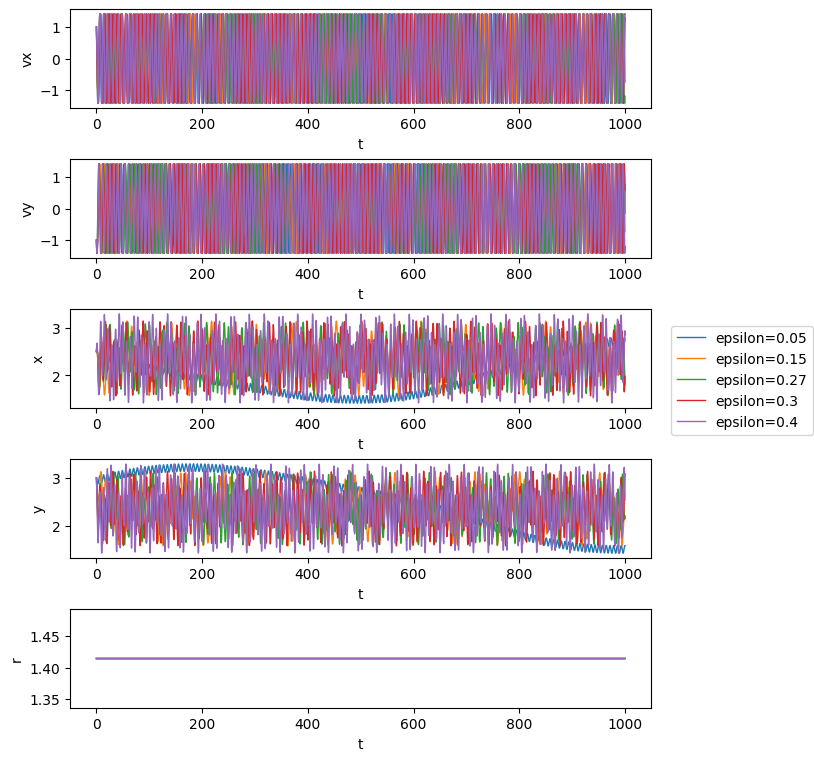

In [ ]:
# Define parameter values and labels
epsilon_list = [0.05, 0.15, 0.27, 0.3, 0.4]
traj_labels = [f"epsilon={epsilon}" for epsilon in epsilon_list]

# Set initial condition index
traj_idx = 3 

# Get reference trajectory filepaths
ref_filepaths = AlphaParticle.get_reference_filepaths("default")

# Load reference trajectories
ref_trajs = [
    Trajectory.load_from_file(
        ref_filepaths[epsilon][traj_idx]["filepath"], 
        dt=ref_filepaths[epsilon][traj_idx]["dt"],
        epsilon=epsilon,) 
    for epsilon in epsilon_list
]

# Display initial conditions for verification
for traj in ref_trajs:
    print(f"Initial state: {traj.states.u[0]}")

# Select time window for analysis (t = 0 to 1000)
trajs = [traj.select_between(0, 1000) for traj in ref_trajs]

# Plot the trajectories in the xy-plane
viz.plot_xy(
    trajs, 
    axis_lims=[(1, 4.5), (1, 4.5)],
    figsize=(6, 5), 
    show_legend=True,
    legend_labels=traj_labels
)

# Plot the time series of various quantities
viz.plot_history(
    trajs,
    func_dict={
        'vx': lambda u: u[:, 0], 
        'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 
        'y': lambda u: u[:, 3], 
        'r': lambda u: np.sqrt(u[:, 0]**2 + u[:, 1]**2),
    },
    xlabel='t', 
    show_legend=True,
    legend_labels=traj_labels
)

### 3. Taylor Series Approximation Validation

We generate Taylor series approximations of orders 1 and 2 around $t=0$ for the dynamics. We validate the computed approximations by comparing against reference trajectory over short time interval ($t$ from 0 to 10). 

Physical significance: 
- Order 1: Linear approximation captures initial velocity direction
- Order 2: Quadratic terms include acceleration effects
- Error Analysis: Reveals limitations of local approximations for long-time integration


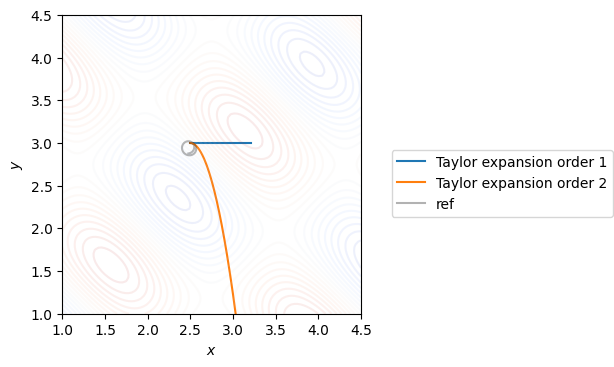

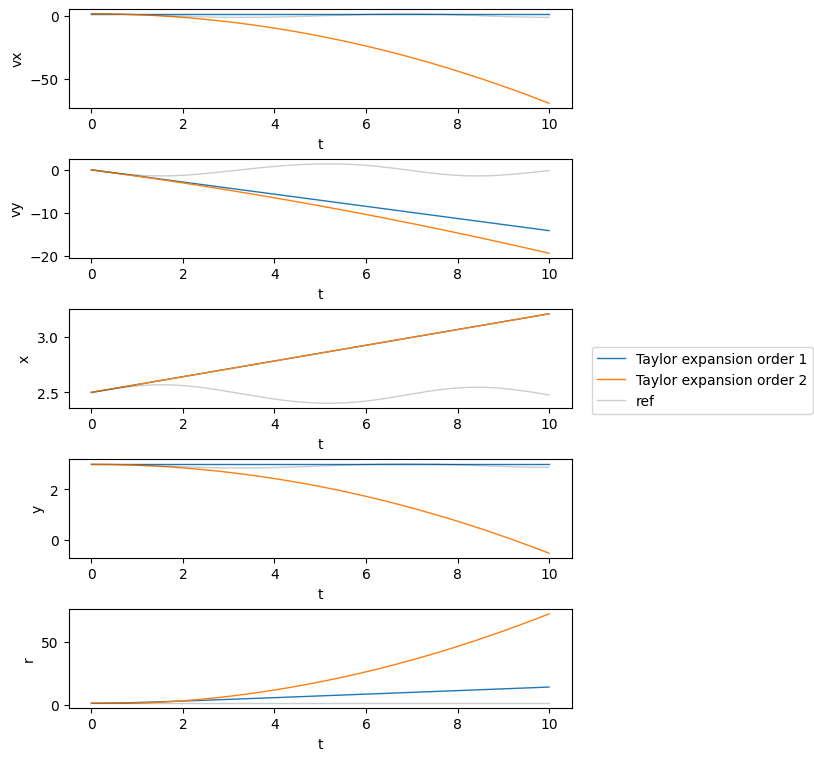

After alignment: 
	traj = AlphaParticleTrajectory(t_range=[0.0, 10.0], dt=0.01, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(1001, 4)))
	ref_traj = AlphaParticleTrajectory(t_range=[0.0, 10.0], dt=0.01, u0=[1.41421356 0.         2.5        3.        ], states=States(problem=AlphaParticle(epsilon=0.05, a1=0.3), shape=(1001, 4)))
Taylor expansion order 1 n=1 abs_traj_err = 7.135767714687484e-05
Taylor expansion order 1 n=1000 abs_traj_err = 14.313279042932463
Taylor expansion order 1 n=1 abs_traj_err_vxvy = 7.126958409898681e-05
Taylor expansion order 1 n=1000 abs_traj_err_vxvy = 14.294115622343199
Taylor expansion order 1 n=1 abs_traj_err_xy = 3.5446396368417213e-06
Taylor expansion order 1 n=1000 abs_traj_err_xy = 0.7404157858485605
Taylor expansion order 1 n=1 abs_H_err = 0.0001004666128980869
Taylor expansion order 1 n=1000 abs_H_err = 100.46661289817281
After alignment: 
	traj = AlphaParticleTrajectory(t_range=[0.

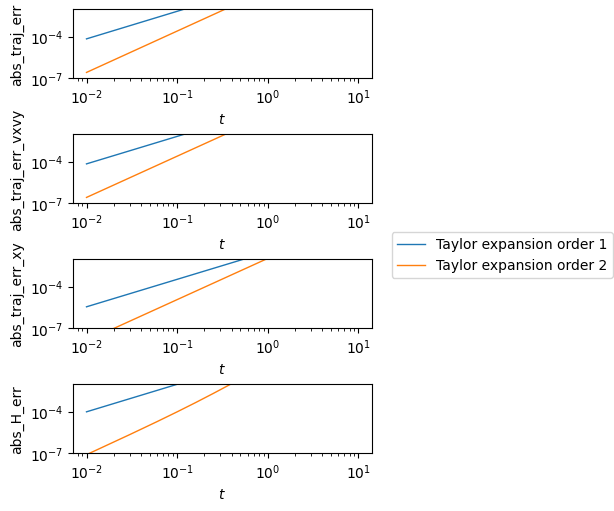

In [ ]:
# Define function to generate Taylor approximations
def trajectory_from_taylor_expansion(u0, times, p, order):
    processor = AlphaParticle(**p)
    u = processor.compute_taylor_series(u0, times, order)
    return Trajectory.from_u(times, u, **p)

# Set parameter
epsilon = 0.05

# Set initial condition index
traj_idx = 1

# Get reference trajectory filepaths
ref_filepaths = AlphaParticle.get_reference_filepaths("default")

# Load reference trajectory
ref_traj = Trajectory.load_from_file(
        ref_filepaths[epsilon][traj_idx]["filepath"], 
        dt=ref_filepaths[epsilon][traj_idx]["dt"],
        epsilon=epsilon)
ref_traj = ref_traj.select_between(0, 10)
u0 = ref_traj.states.u[0]
times = ref_traj.times

# Generate Taylor approximations
taylor_trajs = [trajectory_from_taylor_expansion(u0, times, {"epsilon": epsilon}, order) for order in [1, 2]]
taylor_labels = ['Taylor expansion order {}'.format(i) for i in [1, 2]]

# Plot trajectories in the xy-plane
viz.plot_xy(
    taylor_trajs + [ref_traj], 
    axis_lims=[(1, 4.5), (1, 4.5)],
    figsize=(6, 5), 
    legend_labels=taylor_labels + ['ref'],
    show_legend=True
)

# Plot the time series of various quantities
viz.plot_history(
    taylor_trajs + [ref_traj], 
    func_dict={
        'vx': lambda u: u[:, 0], 
        'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 
        'y': lambda u: u[:, 3], 
        'r': lambda u: np.sqrt(u[:, 0]**2 + u[:, 1]**2),
    },
    xlabel='t', 
    legend_labels=taylor_labels + ['ref'],
    show_legend=True
)

# Plot errors
viz.plot_errors(
    taylor_trajs, ref_traj, 
    error_names=["abs_traj_err", "abs_traj_err_vxvy", "abs_traj_err_xy", "abs_H_err"],
    ylims=[(1e-7, 1e-2)] * 4,
    figsize=(6, 5), 
    legend_labels=taylor_labels,
    show_legend=True,
    log_xscale=True
)

### 4. Poincaré Sections

Poincaré sections provide a powerful tool for analyzing the long-term behavior of dynamical systems by examining the intersections of trajectories with a chosen hypersurface. Here we construct Poincaré sections by recording the particle's position in the xy-plane whenever it crosses $v_y=0$ ($v_y$ changes from negative to positive) during the timespan of (0, 10000).

For each $\epsilon$, we generate 32 orbits by simulating from 32 different initial conditions. As shown in the plots, the dynamics tend to become more chaotic when $\epsilon$ increases. 



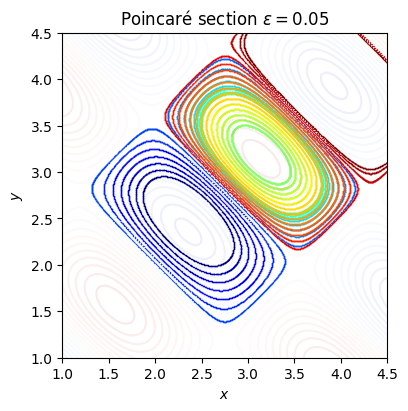

In [8]:
# Set parameter
epsilon = 0.05

# Create processor instance for the specified parameter
processor = AlphaParticle(epsilon=epsilon)

# Get filepaths to pre-computed Poincaré section data
poincare_filepaths = processor.get_poincare_reference_filepaths("default")

# Load all Poincaré section trajectories
# Each trajectory represents a different initial condition or orbit
poincare_trajs = [Trajectory.load_from_file(filepath, epsilon=epsilon) for filepath in poincare_filepaths]

# Visualize the Poincaré sections in the (x,y) plane
# Each trajectory is colored differently to distinguish different orbits
viz.plot_xy(
        poincare_trajs, 
        linestyles='+', 
        markersize=0.3,
        colors=plt.cm.jet(np.linspace(0, 1, len(poincare_trajs))),
        axis_lims=[(1, 4.5), (1, 4.5)], 
        figsize=(5, 4), 
        show_legend=False,
        title=r"Poincaré section $\epsilon=0.05$",
        # save_path=f"./out/alphaparticle/eps=5e-2/poincare32.pdf"
    )

In [ ]:
# Plot using MATLAB
viz.plot_xy_matlab(
        poincare_trajs,
        linestyles='', 
        marker='o', 
        markersize=0.4,
        colors=plt.cm.jet(np.linspace(0, 1, len(poincare_trajs))),
        axis_lims=[(1, 4.5), (1, 4.5)], 
        figsize=(5, 4), 
        # show_legend=False,
        title=r"Poincar\'{e} section $\epsilon=0.05$",
        save_path=f"./out/alphaparticle/eps=5e-2/poincare32.pdf"
    )

Current figure size: 5.0" x 4.0"
New figure size: 3.0" x 2.4"
Saved figure as: ./out/alphaparticle/eps=5e-2/poincare32.pdf and ./out/alphaparticle/eps=5e-2/poincare32.fig
